In [32]:
#imports, may need to install packages via pip
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.io import arff

In [33]:
#reading in the data
arff_file = arff.loadarff('data/raw/1year.arff')
df = pd.DataFrame(arff_file[0])
df

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.200550,0.37951,0.39641,2.04720,32.3510,0.388250,0.249760,1.330500,1.13890,0.504940,...,0.121960,0.397180,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.42770,b'0'
1,0.209120,0.49988,0.47225,1.94470,14.7860,0.000000,0.258340,0.996010,1.69960,0.497880,...,0.121300,0.420020,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.98700,b'0'
2,0.248660,0.69592,0.26713,1.55480,-1.1523,0.000000,0.309060,0.436950,1.30900,0.304080,...,0.241140,0.817740,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.20780,b'0'
3,0.081483,0.30734,0.45879,2.49280,51.9520,0.149880,0.092704,1.866100,1.05710,0.573530,...,0.054015,0.142070,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.54970,b'0'
4,0.187320,0.61323,0.22960,1.40630,-7.3128,0.187320,0.187320,0.630700,1.15590,0.386770,...,0.134850,0.484310,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.89800,b'0'
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7022,0.018371,0.47410,-0.13619,0.60839,-18.4490,0.018371,0.018371,0.972030,1.01210,0.460840,...,0.011909,0.039866,0.98809,0.274140,73.5050,79.2370,31.268,11.6730,5.14890,b'1'
7023,-0.013359,0.58354,-0.02265,0.92896,-42.2320,-0.013359,-0.015036,0.562890,0.98904,0.328470,...,-0.011082,-0.040671,1.01110,0.805920,10.5990,7.1740,94.092,3.8792,1.75720,b'1'
7024,0.006338,0.50276,0.43923,1.87360,9.7417,0.006338,0.012022,0.983560,1.00830,0.494490,...,0.008258,0.012817,0.99174,0.000000,10.4700,6.0759,51.019,7.1542,62.00100,b'1'
7025,-0.041643,0.84810,-0.12852,0.57485,-121.9200,0.000000,-0.036795,0.179010,0.42138,0.151820,...,-0.232720,-0.274290,0.98788,3.593100,39.7030,3.1420,261.850,1.3939,0.51005,b'1'


In [34]:
#renaming columns of the dataframe
#instead of doing this, could instead rename each elem to x1,x2,...xN to save space
#then xN could be attached to a dictionary that when given xN gives back the proper column name
attrNameFile = open('attributenames.txt', 'r')
newNames = attrNameFile.readlines()
attrNameFile.close()
count = 0
for i in range(len(newNames)):
    newNames[i] = (newNames[i].strip())[newNames[i].find("\t")+1:]
ogNames = df.columns

for i in range(len(ogNames)):
    df.rename(columns={ogNames[i] : newNames[i]},inplace=True)
df.rename(columns={'':'bankrupt'},inplace=True)
print(df.columns.to_numpy())


['net profit / total assets' 'total liabilities / total assets'
 'working capital / total assets'
 'current assets / short-term liabilities'
 '[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365'
 'retained earnings / total assets' 'EBIT / total assets'
 'book value of equity / total liabilities' 'sales / total assets'
 'equity / total assets'
 '(gross profit + extraordinary items + financial expenses) / total assets'
 'gross profit / short-term liabilities'
 '(gross profit + depreciation) / sales'
 '(gross profit + interest) / total assets'
 '(total liabilities * 365) / (gross profit + depreciation)'
 '(gross profit + depreciation) / total liabilities'
 'total assets / total liabilities' 'gross profit / total assets'
 'gross profit / sales' '(inventory * 365) / sales'
 'sales (n) / sales (n-1)' 'profit on operating activities / total assets'
 'net profit / sales' 'gross profit (in 3 years) / total assets'
 '(equity - shar

In [35]:
#visualizing the head of the dataframe
df.head()

,net profit / total assets,total liabilities / total assets,working capital / total assets,current assets / short-term liabilities,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,retained earnings / total assets,EBIT / total assets,book value of equity / total liabilities,sales / total assets,equity / total assets,...,(sales - cost of products sold) / sales,(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation),total costs /total sales,long-term liabilities / equity,sales / inventory,sales / receivables,(short-term liabilities *365) / sales,sales / short-term liabilities,sales / fixed assets,bankrupt
0,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,0.50494,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,b'0'
1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,0.49788,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,b'0'
2,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,0.30408,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,b'0'
3,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,0.57353,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,b'0'
4,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,0.38677,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,b'0'


In [36]:
#visualizing the tail of the dataframe
df.tail()

,net profit / total assets,total liabilities / total assets,working capital / total assets,current assets / short-term liabilities,[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,retained earnings / total assets,EBIT / total assets,book value of equity / total liabilities,sales / total assets,equity / total assets,...,(sales - cost of products sold) / sales,(current assets - inventory - short-term liabilities) / (sales - gross profit - depreciation),total costs /total sales,long-term liabilities / equity,sales / inventory,sales / receivables,(short-term liabilities *365) / sales,sales / short-term liabilities,sales / fixed assets,bankrupt
7022,0.018371,0.47410,-0.13619,0.60839,-18.4490,0.018371,0.018371,0.972030,1.01210,0.460840,...,0.011909,0.039866,0.98809,0.27414,73.505,79.2370,31.268,11.6730,5.14890,b'1'
7023,-0.013359,0.58354,-0.02265,0.92896,-42.2320,-0.013359,-0.015036,0.562890,0.98904,0.328470,...,-0.011082,-0.040671,1.01110,0.80592,10.599,7.1740,94.092,3.8792,1.75720,b'1'
7024,0.006338,0.50276,0.43923,1.87360,9.7417,0.006338,0.012022,0.983560,1.00830,0.494490,...,0.008258,0.012817,0.99174,0.00000,10.470,6.0759,51.019,7.1542,62.00100,b'1'
7025,-0.041643,0.84810,-0.12852,0.57485,-121.9200,0.000000,-0.036795,0.179010,0.42138,0.151820,...,-0.232720,-0.274290,0.98788,3.59310,39.703,3.1420,261.850,1.3939,0.51005,b'1'
7026,0.014946,0.94648,0.03211,1.03630,-20.5810,0.000000,0.015260,0.056357,2.96940,0.053341,...,0.015705,0.280210,0.97443,1.17920,15.036,4.1741,108.640,3.3599,35.11800,b'1'


In [37]:
#visualizng the data types of the data frame (they are all floats with the exception of bankrupt which is an obj)
df.dtypes

net profit / total assets                                                                                              float64
total liabilities / total assets                                                                                       float64
working capital / total assets                                                                                         float64
current assets / short-term liabilities                                                                                float64
[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365    float64
                                                                                                                        ...   
sales / receivables                                                                                                    float64
(short-term liabilities *365) / sales                                                                          

In [38]:
#Checking which columns do not use float64 dtype (all except bankrupt/target)
nonFloatValues = df.dtypes
for label,dtype in nonFloatValues.items():
    if(dtype == "float64"):
        nonFloatValues.pop(label)
nonFloatValues

bankrupt    object
dtype: object

In [39]:
#visualzing the value of bankrupt
df["bankrupt"]

0       b'0'
1       b'0'
2       b'0'
3       b'0'
4       b'0'
        ... 
7022    b'1'
7023    b'1'
7024    b'1'
7025    b'1'
7026    b'1'
Name: bankrupt, Length: 7027, dtype: object

In [40]:
# bankrupt companies at tail, successful companies at head, must shuffle data set in pre-process
# may need to convert the current format b'1' to 1 (int) in pre process
df["bankrupt"].astype('int')

0       0
1       0
2       0
3       0
4       0
       ..
7022    1
7023    1
7024    1
7025    1
7026    1
Name: bankrupt, Length: 7027, dtype: int64

In [41]:
#visualizing the amount of bankrupt vs not bankrupt companies
df['bankrupt'] = df["bankrupt"].astype('int')
non_bankrupt = df.loc[df['bankrupt'] == 0]
print("number of non-bankrupt companies:", len(non_bankrupt))
bankrupt = df.loc[df['bankrupt'] == 1]
print("number of bankrupt companies:", len(bankrupt))

number of non-bankrupt companies: 6756
number of bankrupt companies: 271


<Axes: >

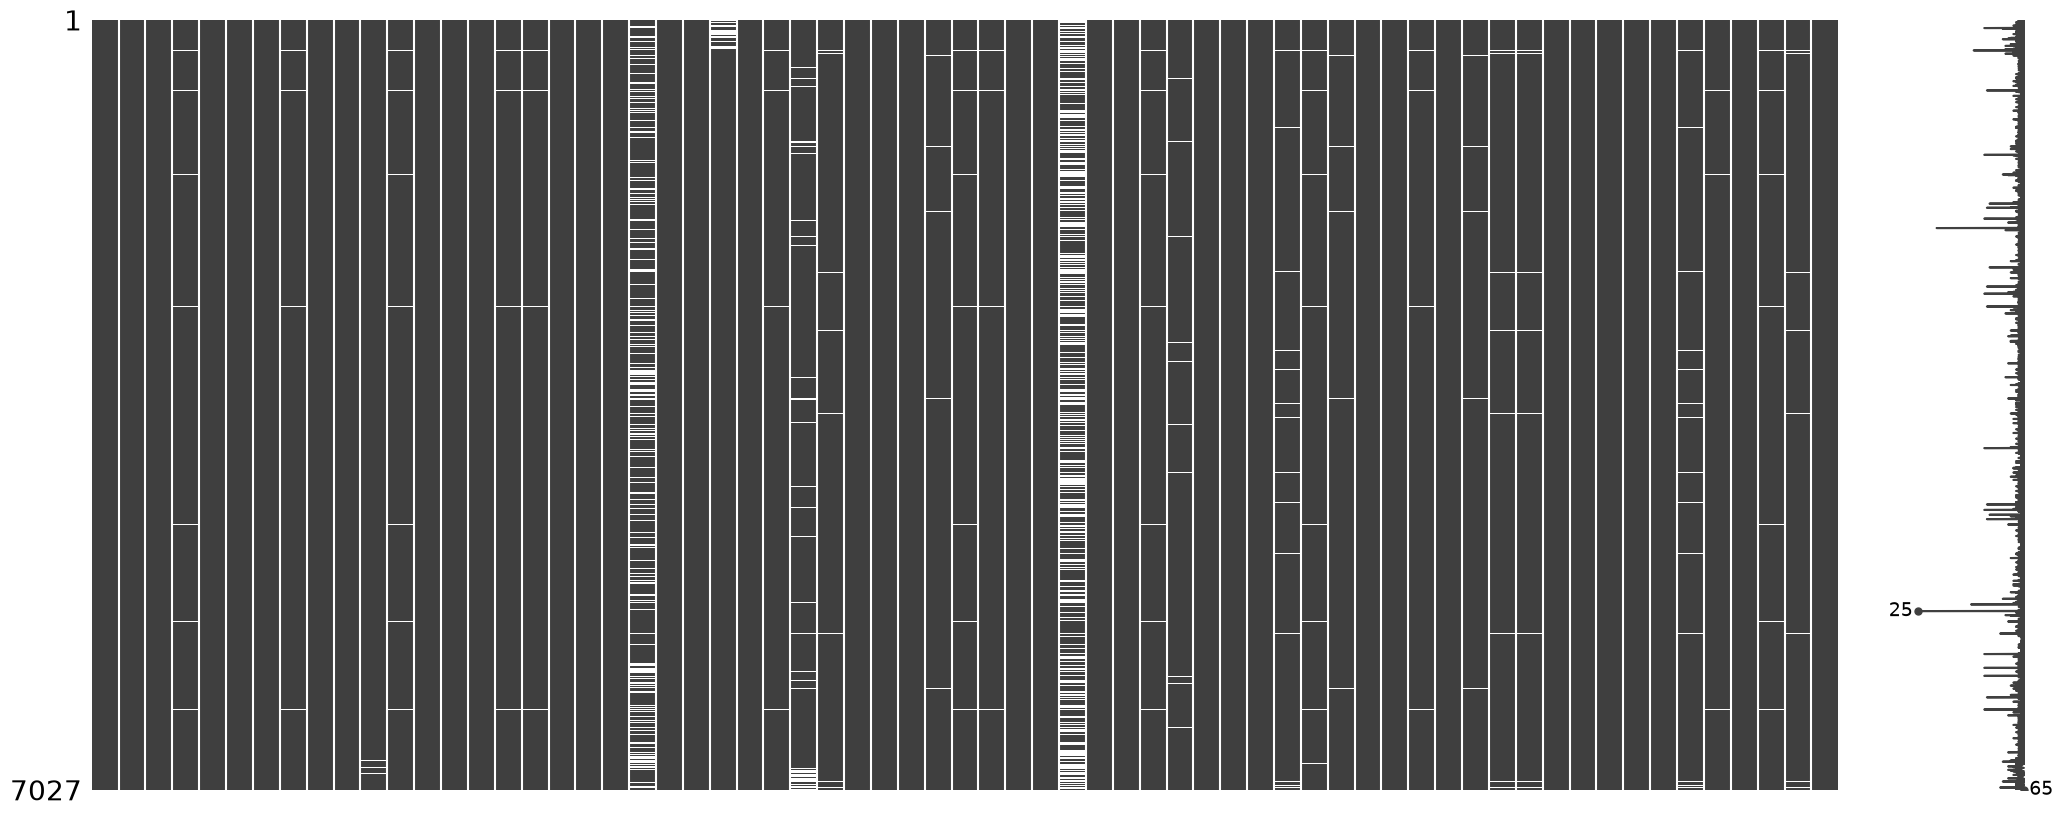

In [42]:
#missingno matrix representation of columns,rows and missing values
import missingno

missingno.matrix(df)

In [43]:
#sum of each columns missing values (minimum x values missing) in descending order
missingValues = df.isna().sum()
for col,val in missingValues.items():
    if(val < 1): # can change if wanting to show columns with more than x missing values
        missingValues.pop(col)
missingValues.sort_values(ascending=False)


(current assets - inventories) / long-term liabilities                                                                 2740
sales (n) / sales (n-1)                                                                                                1622
profit on operating activities / financial expenses                                                                     311
sales / inventory                                                                                                       135
net profit / inventory                                                                                                  134
gross profit (in 3 years) / total assets                                                                                124
total liabilities / ((profit on operating activities + depreciation) * (12/365))                                         84
(gross profit + extraordinary items + financial expenses) / total assets                                                 39
(current

In [44]:
#the number of rows with missing values
drop_missing_rows = df.dropna()
print("there are", len(df) - len(drop_missing_rows),"rows with missing values")

there are 3833 rows with missing values


In [45]:
#the number of duplicate rows 
duplicated = df[df.duplicated()]
print("there are", len(duplicated),"rows with duplicate values")

there are 82 rows with duplicate values


In [46]:
# number of rows after removing duplicates and null values
# some na rows may also be duplicates which is why:
# len(df) - len(drop_missing_rows) - len(duplicated) does not equal len(perfect_rows)
# note: perfect rows is an exploration into how the data would look with bad rows removed, this is not pre processing 
perfect_rows = df.dropna().drop_duplicates()
print("after removing duplicates and rows with null values there are", len(perfect_rows), "rows remaining" )

after removing duplicates and rows with null values there are 3151 rows remaining


<Axes: >

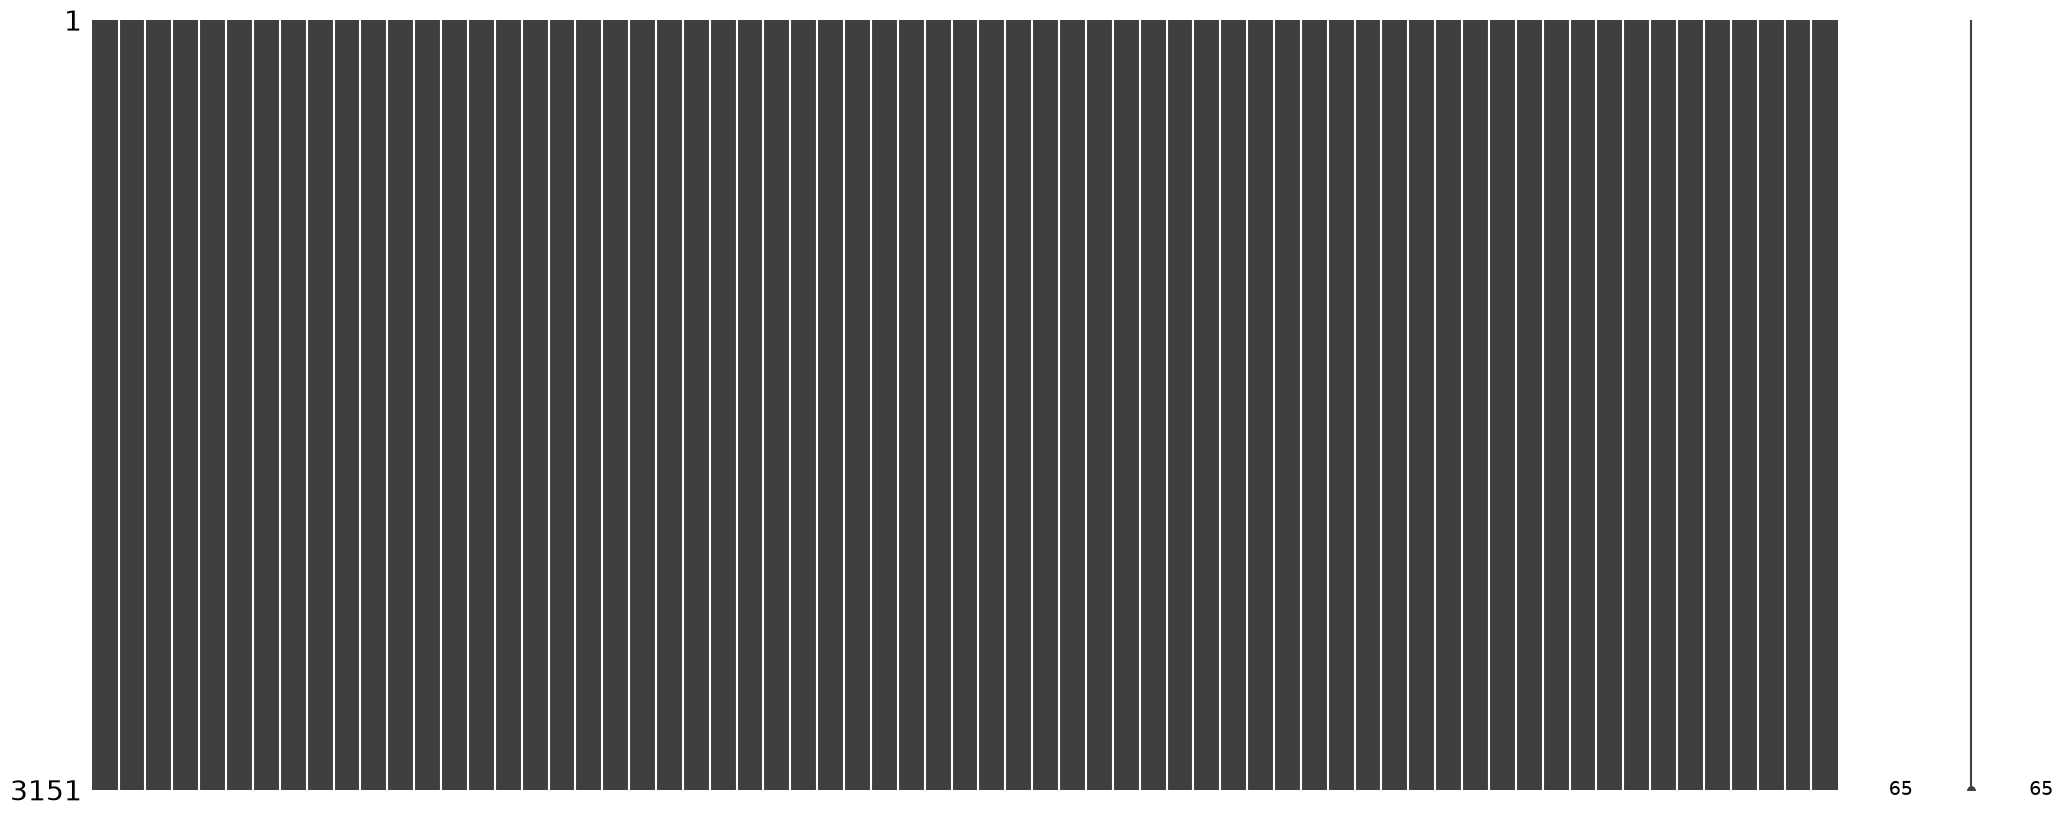

In [47]:
# missingno matrix of "perfect_rows" (no missing or duplicate rows)
missingno.matrix(perfect_rows)

In [48]:
#number of bankrupt and non-bankrupt companies in perfect rows 
non_bankrupt = perfect_rows.loc[perfect_rows['bankrupt'] == 0]
print("number of non-bankrupt companies with perfect rows:", len(non_bankrupt))
bankrupt = perfect_rows.loc[perfect_rows['bankrupt'] == 1]
print("number of bankrupt companies with perfect rows:", len(bankrupt))

number of non-bankrupt companies with perfect rows: 3121
number of bankrupt companies with perfect rows: 30


In [49]:
'''
CONCLUSIONS:

- Columns need to be renamed to their full name or instead of doing that, could instead rename each elem to x1,x2,...xN to save space
  then xN could be attached to a dictionary that when given xN gives back the proper column name
- values (floats) should be normalized (I think?) EXCEPT BANKRUPT/TARGET (Already normalized)
- all of the data except bankrupt uses
- The value of the bankrupt/target column should be changed from bits to intergers or floats
- shuffling the data is neccessary in order to mix bankrupt and non-bankrupt companies
- removing rows removes a great number of bankrupt companies
- regardless of whether or not rows are removed some oversampling/undersampling is needed in order to create a solid dataset

SIDENOTE: THIS HAS BEEN DONE FOR ONE OF THE FIVE DATASETS, FOR THE OTHER FOUR COPYING THIS NOTEBOOK AND REPLACING THE DATA WITH
          THE DATA FROM THAT DATASET SHOULD ALLOW FOR A SIMILAR DATA VISUALIZATION
'''

'\nCONCLUSIONS:\n\n- Columns need to be renamed to their full name or instead of doing that, could instead rename each elem to x1,x2,...xN to save space\n  then xN could be attached to a dictionary that when given xN gives back the proper column name\n- values (floats) should be normalized (I think?) EXCEPT BANKRUPT/TARGET (Already normalized)\n- all of the data except bankrupt uses\n- The value of the bankrupt/target column should be changed from bits to intergers or floats\n- shuffling the data is neccessary in order to mix bankrupt and non-bankrupt companies\n- removing rows removes a great number of bankrupt companies\n- regardless of whether or not rows are removed some oversampling/undersampling is needed in order to create a solid dataset\n\nSIDENOTE: THIS HAS BEEN DONE FOR ONE OF THE FIVE DATASETS, FOR THE OTHER FOUR COPYING THIS NOTEBOOK AND REPLACING THE DATA WITH\n          THE DATA FROM THAT DATASET SHOULD ALLOW FOR A SIMILAR DATA VISUALIZATION\n'

In [50]:
#missing counts and percentages for the 15 columns with the most missing values
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing Percent": missing_percent
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percent", ascending=False)

missing_summary.head(15)

,Missing Count,Missing Percent
(current assets - inventories) / long-term liabilities,2740,38.992458
sales (n) / sales (n-1),1622,23.082396
profit on operating activities / financial expenses,311,4.425786
sales / inventory,135,1.921161
net profit / inventory,134,1.906930
gross profit (in 3 years) / total assets,124,1.764622
total liabilities / ((profit on operating activities + depreciation) * (12/365)),84,1.195389
(gross profit + extraordinary items + financial expenses) / total assets,39,0.555002
(current liabilities * 365) / cost of products sold,38,0.540771
constant capital / fixed assets,34,0.483848


In [51]:
#percentage of rows with missing values, using the earlier row count
percent_rows_with_missing = (len(df) - len(drop_missing_rows)) / len(df) * 100
print("Percentage of rows with at least one missing value:", round(percent_rows_with_missing, 2), "%")

Percentage of rows with at least one missing value: 54.55 %


In [52]:
#missing values by class before removing duplicates (0 = non-bankrupt, 1 = bankrupt)
has_missing = df.isna().any(axis=1)
missing_by_class = (
    df.assign(has_missing=has_missing)
    .groupby("bankrupt")["has_missing"]
    .agg(Total="size", Missing="sum")
)
missing_by_class["Complete"] = missing_by_class["Total"] - missing_by_class["Missing"]
missing_by_class["Missing Percent"] = 100 * missing_by_class["Missing"] / missing_by_class["Total"]
missing_by_class.round(2)

,Total,Missing,Complete,Missing Percent
bankrupt,,,,
0,6756,3592,3164,53.17
1,271,241,30,88.93


In [ ]:
#missing counts and percentages for each feature by class
#largest percentage gaps first, positive means more missing values in bankrupt companies
#You will likely have to scroll to the right when analyzing this output
feature_missing = df.drop(columns="bankrupt").isna()
feature_missing_by_class = pd.DataFrame({
    "Non-bankrupt Missing Count": feature_missing.loc[df["bankrupt"].eq(0)].sum(),
    "Bankrupt Missing Count": feature_missing.loc[df["bankrupt"].eq(1)].sum(),
    "Non-bankrupt Missing Percent": 100 * feature_missing.loc[df["bankrupt"].eq(0)].mean(),
    "Bankrupt Missing Percent": 100 * feature_missing.loc[df["bankrupt"].eq(1)].mean(),
})
feature_missing_by_class["Gap (percentage points)"] = (
    feature_missing_by_class["Bankrupt Missing Percent"]
    - feature_missing_by_class["Non-bankrupt Missing Percent"]
)
feature_missing_by_class = feature_missing_by_class.loc[feature_missing.any()]
feature_missing_by_class = feature_missing_by_class.loc[
    feature_missing_by_class["Gap (percentage points)"].abs().sort_values(ascending=False).index
]
with pd.option_context("display.max_rows", None, "display.max_columns", None):
    print(feature_missing_by_class.round(2).to_string())

                                                                                                                     Non-bankrupt Missing Count  Bankrupt Missing Count  Non-bankrupt Missing Percent  Bankrupt Missing Percent  Gap (percentage points)
profit on operating activities / financial expenses                                                                                         191                     120                          2.83                     44.28                    41.45
sales (n) / sales (n-1)                                                                                                                    1513                     109                         22.39                     40.22                    17.83
(gross profit + extraordinary items + financial expenses) / total assets                                                                      3                      36                          0.04                     13.28                    13.24
net 

In [ ]:
#duplicate rows by class and how many also have missing values
#counts repeated rows after the first, using all columns
is_duplicate = df.duplicated()
duplicate_by_class = (
    df.assign(duplicate=is_duplicate, missing_and_duplicate=has_missing & is_duplicate)
    .groupby("bankrupt")
    .agg(Total=("duplicate", "size"),
         Duplicate_Rows=("duplicate", "sum"),
         Missing_And_Duplicate=("missing_and_duplicate", "sum"))
)
duplicate_by_class["Duplicate Percent"] = 100 * duplicate_by_class["Duplicate_Rows"] / duplicate_by_class["Total"]
duplicate_by_class.round(2)


,Total,Duplicate_Rows,Missing_And_Duplicate,Duplicate Percent
bankrupt,,,,
0,6756,82,39,1.21
1,271,0,0,0.00


In [ ]:
'''
FURTHER CONCLUSIONS:

- 88.93% of bankrupt rows have missing values, compared to 53.17% of non-bankrupt rows
- all 82 duplicate rows are non-bankrupt, 39 also have missing values

- removing missing rows alone reduces bankrupt cases from 271 to 30
-We will therefore fill in the missing values instead of dropping rows (fit only on the training data)

- scaling and oversampling/undersampling should depend on the model and evaluation results
- operating profit / financial expenses is missing in 44.28% of bankrupt companies versus 2.83% of non-bankrupt companies
- some ratios have extreme values far beyond their usual range; inspect them and compare preprocessing before removing data
'''

'\nFURTHER CONCLUSIONS:\n\n- 88.93% of bankrupt rows have missing values, compared to 53.17% of non-bankrupt rows\n- all 82 duplicate rows are non-bankrupt; 39 also have missing values\n- removing missing rows alone reduces bankrupt cases from 271 to 30\n- consider filling missing values instead of dropping rows; fit this on training data only\n- scaling and oversampling/undersampling should depend on the model and evaluation results\n- operating profit / financial expenses is missing in 44.28% of bankrupt companies versus 2.83% of non-bankrupt companies\n- some ratios have extreme values far beyond their usual range; inspect them and compare preprocessing before removing data\n'

In [56]:
#minimum, median and maximum of each feature (excluding bankrupt)
#missing values are skipped; df is not changed
feature_distribution_summary = df.drop(columns="bankrupt").describe().T
feature_distribution_summary = feature_distribution_summary[["min", "25%", "50%", "75%", "max"]]
feature_distribution_summary.columns = ["Min", "Q1", "Median", "Q3", "Max"]
feature_distribution_summary.round(2)

,Min,Q1,Median,Q3,Max
net profit / total assets,-256.89,0.02,0.08,0.16,94.28
total liabilities / total assets,-72.16,0.30,0.48,0.68,441.50
working capital / total assets,-440.50,0.03,0.18,0.36,1.00
current assets / short-term liabilities,0.00,1.06,1.50,2.46,1017.80
[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365,-2722100.00,-44.50,-5.37,37.77,990900.00
...,...,...,...,...,...
sales / inventory,0.00,5.92,10.04,20.14,2137800.00
sales / receivables,0.00,4.83,7.03,10.70,21110.00
(short-term liabilities *365) / sales,0.00,43.22,68.51,106.34,25016000.00
sales / short-term liabilities,0.00,3.43,5.30,8.36,1042.20


In [57]:
#features with the most extreme values relative to their usual spread
#IQR is the middle 50% of values; a large score is a reason to inspect, not delete
feature_iqr = feature_distribution_summary["Q3"] - feature_distribution_summary["Q1"]
extreme_distance = pd.concat([
    feature_distribution_summary["Max"] - feature_distribution_summary["Median"],
    feature_distribution_summary["Median"] - feature_distribution_summary["Min"]
], axis=1).max(axis=1)
extreme_features = feature_distribution_summary.copy()
extreme_features["Extreme Distance / IQR"] = extreme_distance / feature_iqr.replace(0, np.nan)
extreme_features = extreme_features.sort_values("Extreme Distance / IQR", ascending=False)
extreme_features.head(5).round(2)

,Min,Q1,Median,Q3,Max,Extreme Distance / IQR
total costs /total sales,-0.00,0.86,0.94,0.98,1108300.0,9452444.02
(sales - cost of products sold) / sales,-1108300.00,0.02,0.06,0.14,1.0,9441943.62
(total liabilities - cash) / sales,-149.07,0.09,0.21,0.37,152860.0,564154.04
(receivables * 365) / sales,0.00,33.87,51.80,75.50,22584000.0,542498.67
rotation receivables + inventory turnover in days,0.00,65.26,94.61,130.42,30393000.0,466442.17


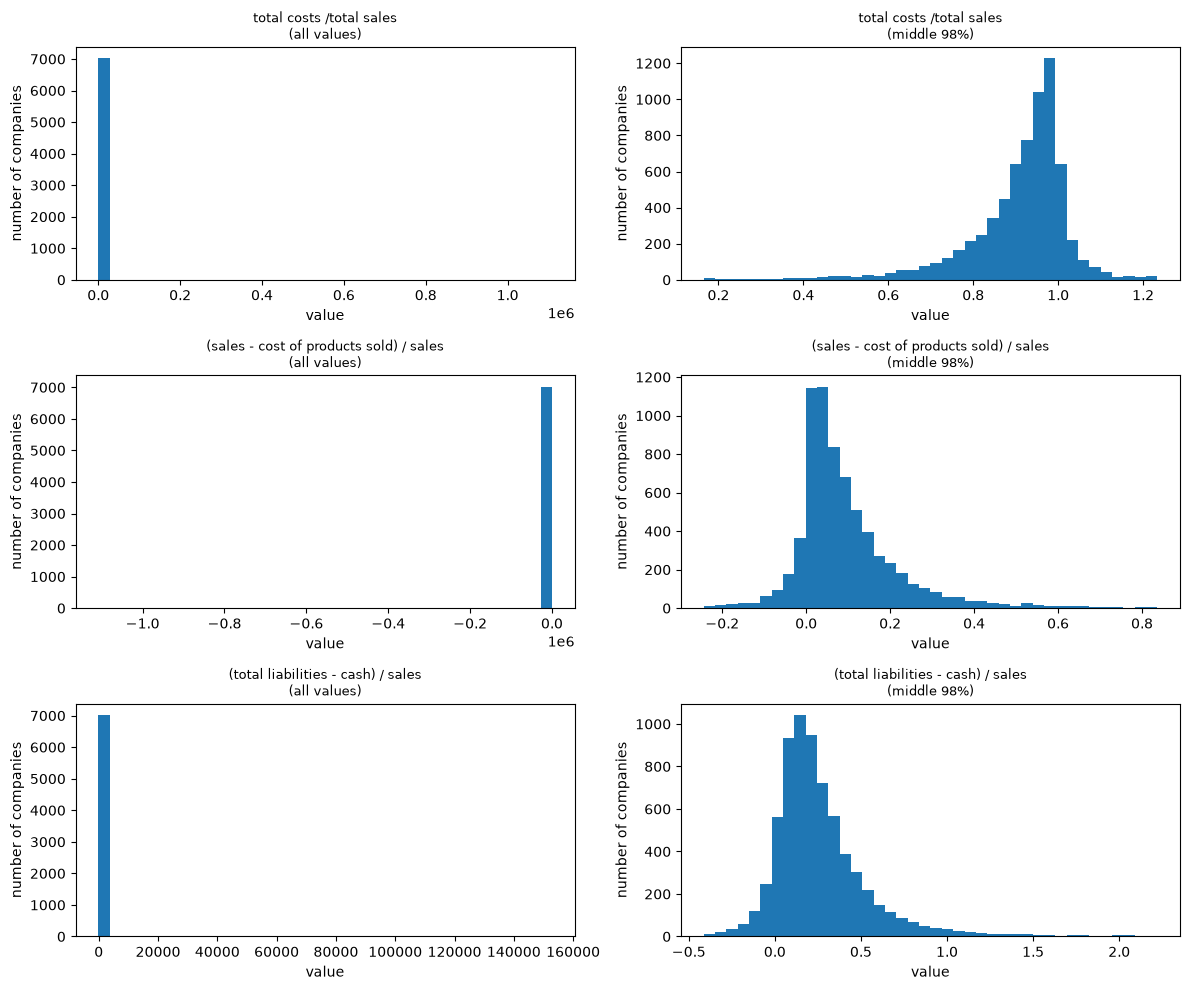

In [58]:
#distributions of the three features with the largest extreme-value scores
#left shows all values; right zooms in on the middle 98% without changing df
plot_features = extreme_features["Extreme Distance / IQR"].dropna().head(3).index
fig, axes = plt.subplots(len(plot_features), 2, figsize=(12, 10), squeeze=False)
for i, col in enumerate(plot_features):
    values = df[col].dropna()
    low, high = values.quantile([0.01, 0.99])
    axes[i, 0].hist(values, bins=40)
    axes[i, 1].hist(values[values.between(low, high)], bins=40)
    for j, label in enumerate(["all values", "middle 98%"]):
        axes[i, j].set_title(f"{col}\n({label})", fontsize=9, wrap=True)
        axes[i, j].set_xlabel("value")
        axes[i, j].set_ylabel("number of companies")
plt.tight_layout()
plt.show()

In [59]:
#load all five datasets without changing the original files
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.io import arff

with open("attributenames.txt") as file:
    names = file.readlines()
names = [s.strip()[s.find("\t") + 1:] for s in names]

datasets = {}
for year in range(1, 6):
    data = pd.DataFrame(arff.loadarff(f"data/raw/{year}year.arff")[0])
    data.columns = names
    data.rename(columns={"": "bankrupt"}, inplace=True)
    data["bankrupt"] = data["bankrupt"].astype(int)
    datasets[year] = data

In [ ]:
#compare all five files
# Note to self 1year.arff predicts 5 years ahead 5year.arff predicts 1 year ahead
summary_rows = []
for year, data in datasets.items():
    summary_rows.append({
        "File": f"{year}year.arff",
        "Years Ahead": 6 - year,
        "Rows": len(data),
        "Bankrupt": int(data["bankrupt"].sum()),
        "Bankrupt Percent": data["bankrupt"].mean() * 100,
        "Rows With Missing Values": int(data.isna().any(axis=1).sum()),
        "Missing Row Percent": data.isna().any(axis=1).mean() * 100,
        "Duplicate Rows": int(data.duplicated().sum())
    })
dataset_summary = pd.DataFrame(summary_rows).set_index("File")
dataset_summary.round(2)

,Years Ahead,Rows,Bankrupt,Bankrupt Percent,Rows With Missing Values,Missing Row Percent,Duplicate Rows
File,,,,,,,
1year.arff,5,7027,271,3.86,3833,54.55,82
2year.arff,4,10173,400,3.93,6085,59.82,90
3year.arff,3,10503,495,4.71,5618,53.49,87
4year.arff,2,9792,515,5.26,5023,51.30,82
5year.arff,1,5910,410,6.94,2879,48.71,60
